In [11]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [12]:
load_dotenv()

True

In [ ]:
from langchain_groq import ChatGroq
model = ChatGroq(model = "llama-3.3-70b-versatile")
print(model)

output_version=None profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000001F339EF5090> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F339EF5BD0> model_name='llama-3.3-70b-versatile' model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None


In [14]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str

In [15]:

def create_outline(state : BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content
    state['outline'] = outline 
    return state

In [6]:
from langchain_core.messages import content

def create_blog(state : BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [7]:
graph = StateGraph(BlogState)


In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [9]:
workflow = graph.compile()

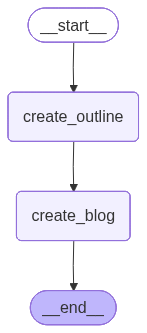

In [10]:
workflow

In [16]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its increasing importance globally\n* Importance of AI in India\'s economic growth and development\n* Thesis statement: India is witnessing a significant rise in AI adoption, driven by government initiatives, technological advancements, and increasing demand for AI-powered solutions.\n\n**II. Current State of AI in India**\n\n* Overview of India\'s AI ecosystem, including key players, startups, and research institutions\n* Discussion of the current AI landscape in India, including:\n\t+ AI adoption in various industries (e.g., healthcare, finance, manufacturing)\n\t+ AI research and development in Indian universities and institutions\n\t+ Government initiatives and policies supporting AI growth\n* Statistics and data on AI adoption, investment, and job creation in India\n\n**III. Drivers of 

In [17]:
print(final_state['title'])

Rise of AI in India


In [54]:
print(final_state['outline'])

Here's a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Importance of AI in India's economic growth and development
* Thesis statement: India is witnessing a significant rise in the adoption and development of AI, with the government, industries, and startups contributing to its growth.

**II. Current State of AI in India**

* Overview of India's AI ecosystem, including the number of AI startups, funding, and job market
* Discussion of the key sectors where AI is being adopted, such as:
	+ Healthcare
	+ Finance
	+ Education
	+ Manufacturing
* Examples of Indian companies that are already using AI, such as:
	+ Tata Consultancy Services (TCS)
	+ Infosys
	+ Wipro

**III. Government Initiatives and Policies**

* Overview of the Indian government's initiatives to promote AI, such as:
	+ National AI Strategy
	+ AI Task Force
	+ NITI Aayog's AI initiative
* Discussion 

In [1]:
print(final_state['content'])

NameError: name 'final_state' is not defined